# NYC Yellow Taxi — Trip Duration Prediction

A complete ML pipeline. No tracking. No versioning.

This notebook trains **6 models** on the NYC taxi dataset and picks the best one.

**What it does NOT do:** track any of it. When you close this notebook, the models you trained, their hyperparameters, their metrics, and their comparison — all gone. That's the problem the next notebook solves.

## 1. Setup

In [2]:
import warnings
warnings.filterwarnings('ignore')

import os
import time
import joblib
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

print(f"numpy {np.__version__}")
print(f"pandas {pd.__version__}")

numpy 2.3.5
pandas 2.3.3


In [3]:
class Config:
    """Centralized configuration — every constant in one place."""

    # Reproducibility
    RANDOM_STATE = 42
    TEST_SIZE = 0.2
    VAL_SIZE = 0.2
    CV_FOLDS = 5
    N_JOBS = -1

    # Output
    MODEL_DIR = "models_nyc_taxi"

    # Data cleaning
    MIN_TRIP_DURATION = 60        # seconds
    MAX_TRIP_DURATION = 7200      # seconds
    MIN_TRIP_DISTANCE = 0.1       # miles
    MAX_TRIP_DISTANCE = 50        # miles
    NYC_LAT_RANGE = (40.5, 40.9)
    NYC_LON_RANGE = (-74.3, -73.7)
    IQR_FACTOR = 1.5

    # Model hyperparameters
    RF_N_ESTIMATORS = 100
    RF_MAX_DEPTH = 20
    RF_MIN_SAMPLES_SPLIT = 10

    GB_N_ESTIMATORS = 100
    GB_LEARNING_RATE = 0.1
    GB_MAX_DEPTH = 5

    RIDGE_ALPHA = 10.0
    LASSO_ALPHA = 0.1
    ELASTIC_ALPHA = 0.1
    ELASTIC_L1_RATIO = 0.5


config = Config()
os.makedirs(config.MODEL_DIR, exist_ok=True)

print(f"Random state: {config.RANDOM_STATE}")
print(f"Model dir:    {config.MODEL_DIR}")

Random state: 42
Model dir:    models_nyc_taxi


## 2. Load Data

The dataset is tracked with DVC — the same mechanism from Lesson 2.1. The `.dvc` pointer lives in git; the actual CSV lives in the DVC remote. `dvc pull` retrieves it.

In [4]:
# Pull the dataset from the DVC remote
!dvc pull data/sample_nyc_taxi.csv.dvc

df = pd.read_csv("data/sample_nyc_taxi.csv")
print(f"Loaded {len(df):,} rows × {df.shape[1]} columns")
df.head(3)

/bin/bash: line 1: dvc: command not found
Loaded 100,000 rows × 19 columns


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RatecodeID,store_and_fwd_flag,dropoff_longitude,dropoff_latitude,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
0,1,2016-01-04 09:29:53,2016-01-04 10:01:49,1,8.7,-73.874359,40.774021,1,N,-73.990402,40.746815,1,29.0,0.0,0.5,7.05,5.54,0.3,42.39
1,1,2016-01-01 01:25:58,2016-01-01 01:34:06,1,1.5,-73.987724,40.759651,1,N,-73.987411,40.775589,2,8.0,0.5,0.5,0.00,0.00,0.3,9.30
2,2,2016-01-02 17:48:31,2016-01-02 18:03:29,1,2.3,-73.977600,40.755192,1,N,-73.950760,40.770851,1,11.5,0.0,0.5,2.46,0.00,0.3,14.76


## 3. Clean Data

Filter rows that don't make physical sense: durations out of range, distances out of range, coordinates outside NYC, invalid passenger counts.

In [5]:
def clean_nyc_taxi_data(df, config):
    """Filter unrealistic rows. Returns cleaned DataFrame with target column added."""
    df = df.copy()
    initial = len(df)

    # Compute target: trip duration in minutes
    df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])
    df['tpep_dropoff_datetime'] = pd.to_datetime(df['tpep_dropoff_datetime'])
    df['trip_duration_minutes'] = (
        df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']
    ).dt.total_seconds() / 60

    # Duration bounds
    df = df[
        (df['trip_duration_minutes'] >= config.MIN_TRIP_DURATION / 60) &
        (df['trip_duration_minutes'] <= config.MAX_TRIP_DURATION / 60)
    ]

    # Distance bounds
    df = df[
        (df['trip_distance'] >= config.MIN_TRIP_DISTANCE) &
        (df['trip_distance'] <= config.MAX_TRIP_DISTANCE)
    ]

    # Geographic bounds (all four coordinates must be in NYC)
    df = df[
        df['pickup_latitude'].between(*config.NYC_LAT_RANGE) &
        df['pickup_longitude'].between(*config.NYC_LON_RANGE) &
        df['dropoff_latitude'].between(*config.NYC_LAT_RANGE) &
        df['dropoff_longitude'].between(*config.NYC_LON_RANGE)
    ]

    # Passenger count sanity
    df = df[df['passenger_count'].between(1, 6)]

    # No missing values
    df = df.dropna().reset_index(drop=True)

    print(f"Cleaned: {initial:,} → {len(df):,} rows ({len(df)/initial*100:.1f}% kept)")
    print(f"Target: mean={df['trip_duration_minutes'].mean():.1f} min, "
          f"std={df['trip_duration_minutes'].std():.1f} min")
    return df


df_clean = clean_nyc_taxi_data(df, config)

Cleaned: 100,000 → 97,050 rows (97.0% kept)
Target: mean=12.0 min, std=8.9 min


## 4. Define Features

Only features that would be **available at pickup time** are used. Post-trip features (fare, tip, total, dropoff time) are excluded — they would leak the target into the inputs.

In [6]:
PREDICTION_TIME_FEATURES = [
    'tpep_pickup_datetime',
    'pickup_longitude',
    'pickup_latitude',
    'dropoff_longitude',
    'dropoff_latitude',
    'passenger_count',
    'VendorID',
    'RatecodeID',
    'trip_distance',
    'payment_type',
]

LEAKAGE_FEATURES = [
    'fare_amount',
    'tip_amount',
    'total_amount',
    'extra',
    'mta_tax',
    'tolls_amount',
    'improvement_surcharge',
    'store_and_fwd_flag',
    'tpep_dropoff_datetime',
]

X = df_clean[PREDICTION_TIME_FEATURES]
y = df_clean['trip_duration_minutes'].values

print(f"Using {len(PREDICTION_TIME_FEATURES)} prediction-time features")
print(f"Excluded {len(LEAKAGE_FEATURES)} leakage features")
print(f"X: {X.shape}, y: {y.shape}")

Using 10 prediction-time features
Excluded 9 leakage features
X: (97050, 10), y: (97050,)


## 5. Split Train / Val / Test

Split **before** feature engineering. Otherwise statistics computed from the test set leak into training through engineered features.

In [7]:
# First split: hold out test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=config.TEST_SIZE,
    random_state=config.RANDOM_STATE,
)

# Second split: separate validation from training
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=config.VAL_SIZE,
    random_state=config.RANDOM_STATE,
)

print(f"Train: {len(X_train):,}  ({len(X_train)/len(X)*100:.0f}%)")
print(f"Val:   {len(X_val):,}  ({len(X_val)/len(X)*100:.0f}%)")
print(f"Test:  {len(X_test):,}  ({len(X_test)/len(X)*100:.0f}%)")

Train: 62,112  (64%)
Val:   15,528  (16%)
Test:  19,410  (20%)


## 6. Feature Engineering

A custom transformer that computes distance, time, and location features from the raw coordinates and timestamps. Uses only pickup-time information.

In [8]:
class NYCYellowTaxiFeatureEngineer(BaseEstimator, TransformerMixin):
    """Engineer features from raw pickup/dropoff coords and timestamps."""

    def __init__(self):
        self.feature_names_ = []

    def fit(self, X, y=None):
        return self

    @staticmethod
    def haversine_distance(lat1, lon1, lat2, lon2):
        R = 3958.8
        lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
        dlat = lat2 - lat1
        dlon = lon2 - lon1
        a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
        return 2 * R * np.arcsin(np.sqrt(a))

    def transform(self, X):
        X = X.copy()
        X['tpep_pickup_datetime'] = pd.to_datetime(X['tpep_pickup_datetime'])

        # Distance features
        X['haversine_distance'] = self.haversine_distance(
            X['pickup_latitude'], X['pickup_longitude'],
            X['dropoff_latitude'], X['dropoff_longitude'],
        )
        delta_lat = X['dropoff_latitude'] - X['pickup_latitude']
        delta_lon = X['dropoff_longitude'] - X['pickup_longitude']
        X['manhattan_distance'] = np.abs(delta_lat) * 69.0 + np.abs(delta_lon) * 53.0
        X['direction_sin'] = np.sin(np.arctan2(delta_lat, delta_lon))
        X['direction_cos'] = np.cos(np.arctan2(delta_lat, delta_lon))

        # Temporal features
        X['pickup_hour'] = X['tpep_pickup_datetime'].dt.hour
        X['pickup_dayofweek'] = X['tpep_pickup_datetime'].dt.dayofweek
        X['pickup_month'] = X['tpep_pickup_datetime'].dt.month

        # Cyclical encoding
        X['hour_sin'] = np.sin(2 * np.pi * X['pickup_hour'] / 24)
        X['hour_cos'] = np.cos(2 * np.pi * X['pickup_hour'] / 24)
        X['dayofweek_sin'] = np.sin(2 * np.pi * X['pickup_dayofweek'] / 7)
        X['dayofweek_cos'] = np.cos(2 * np.pi * X['pickup_dayofweek'] / 7)

        # Temporal flags
        X['is_rush_hour'] = (
            X['pickup_hour'].between(7, 9) | X['pickup_hour'].between(16, 18)
        ).astype(int)
        X['is_weekend'] = X['pickup_dayofweek'].isin([5, 6]).astype(int)
        X['is_night'] = ((X['pickup_hour'] >= 22) | (X['pickup_hour'] <= 5)).astype(int)

        # Landmark distances
        landmarks = {
            'jfk': (40.6413, -73.7781),
            'lga': (40.7769, -73.8740),
            'times_square': (40.7580, -73.9855),
        }
        for name, (lat, lon) in landmarks.items():
            X[f'pickup_from_{name}'] = self.haversine_distance(
                X['pickup_latitude'], X['pickup_longitude'], lat, lon
            )

        X['is_jfk_trip'] = (X['pickup_from_jfk'] < 2).astype(int)
        X['is_lga_trip'] = (X['pickup_from_lga'] < 2).astype(int)

        # Efficiency
        X['efficiency_ratio'] = X['haversine_distance'] / (X['trip_distance'] + 1e-8)
        X['distance_per_passenger'] = X['trip_distance'] / (X['passenger_count'] + 1e-8)

        # Categorical encodings
        X['is_vendor_2'] = (X['VendorID'] == 2).astype(int)
        X['is_standard_rate'] = (X['RatecodeID'] == 1).astype(int)
        X['is_credit_card'] = (X['payment_type'] == 1).astype(int)

        # Interactions
        X['distance_times_passengers'] = X['trip_distance'] * X['passenger_count']
        X['haversine_times_hour'] = X['haversine_distance'] * X['pickup_hour']

        # Drop originals that are now encoded
        X = X.drop(columns=[
            'tpep_pickup_datetime', 'VendorID', 'RatecodeID', 'payment_type'
        ], errors='ignore')

        numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
        self.feature_names_ = numeric_cols
        return X[numeric_cols].values

    def get_feature_names(self):
        return self.feature_names_

## 7. Outlier Handler

Clip values to IQR bounds. **Fit on training data only** — otherwise the bounds leak from val/test into training.

In [9]:
class OutlierHandler(BaseEstimator, TransformerMixin):
    """IQR-based clipping. Bounds are computed during fit()."""

    def __init__(self, factor=1.5):
        self.factor = factor
        self.lower_bounds_ = None
        self.upper_bounds_ = None

    def fit(self, X, y=None):
        self.lower_bounds_ = []
        self.upper_bounds_ = []
        for i in range(X.shape[1]):
            q1 = np.percentile(X[:, i], 25)
            q3 = np.percentile(X[:, i], 75)
            iqr = q3 - q1
            self.lower_bounds_.append(q1 - self.factor * iqr)
            self.upper_bounds_.append(q3 + self.factor * iqr)
        return self

    def transform(self, X):
        X = X.copy()
        for i in range(X.shape[1]):
            X[:, i] = np.clip(X[:, i], self.lower_bounds_[i], self.upper_bounds_[i])
        return X

## 8. Build Pipeline

Chain the transformer, outlier handler, and scaler. **Fit on training data only.** Transform all three splits with the same fitted pipeline.

In [10]:
preprocessor = Pipeline([
    ('feature_engineer', NYCYellowTaxiFeatureEngineer()),
    ('outlier_handler', OutlierHandler(factor=config.IQR_FACTOR)),
    ('scaler', RobustScaler()),
])

preprocessor.fit(X_train, y_train)

X_train_processed = preprocessor.transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

n_features = len(preprocessor.named_steps['feature_engineer'].get_feature_names())
print(f"Engineered features: {n_features}")
print(f"Train: {X_train_processed.shape}")
print(f"Val:   {X_val_processed.shape}")
print(f"Test:  {X_test_processed.shape}")

Engineered features: 32
Train: (62112, 32)
Val:   (15528, 32)
Test:  (19410, 32)


## 9. Model Portfolio

Six models. Linear baselines for reference, tree ensembles for performance.

In [11]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(random_state=config.RANDOM_STATE, alpha=config.RIDGE_ALPHA),
    'Lasso': Lasso(random_state=config.RANDOM_STATE, alpha=config.LASSO_ALPHA, max_iter=5000),
    'ElasticNet': ElasticNet(random_state=config.RANDOM_STATE, alpha=config.ELASTIC_ALPHA,
                            l1_ratio=config.ELASTIC_L1_RATIO, max_iter=5000),
    'Random Forest': RandomForestRegressor(
        random_state=config.RANDOM_STATE, n_jobs=config.N_JOBS,
        n_estimators=config.RF_N_ESTIMATORS, max_depth=config.RF_MAX_DEPTH,
        min_samples_split=config.RF_MIN_SAMPLES_SPLIT,
    ),
    'Gradient Boosting': GradientBoostingRegressor(
        random_state=config.RANDOM_STATE, n_estimators=config.GB_N_ESTIMATORS,
        learning_rate=config.GB_LEARNING_RATE, max_depth=config.GB_MAX_DEPTH,
    ),
}

print(f"{len(models)} models:")
for name in models:
    print(f"  - {name}")

6 models:
  - Linear Regression
  - Ridge
  - Lasso
  - ElasticNet
  - Random Forest
  - Gradient Boosting


## 10. Train All Models

Loop over the portfolio. Train each on the processed training set, evaluate on validation, print the metrics.

In [12]:
results = {}
trained_models = {}

for name, model in models.items():
    t0 = time.time()
    model.fit(X_train_processed, y_train)
    train_time = time.time() - t0

    y_train_pred = model.predict(X_train_processed)
    y_val_pred = model.predict(X_val_processed)

    metrics = {
        'train_r2': r2_score(y_train, y_train_pred),
        'val_r2': r2_score(y_val, y_val_pred),
        'train_rmse': np.sqrt(mean_squared_error(y_train, y_train_pred)),
        'val_rmse': np.sqrt(mean_squared_error(y_val, y_val_pred)),
        'train_mae': mean_absolute_error(y_train, y_train_pred),
        'val_mae': mean_absolute_error(y_val, y_val_pred),
        'training_time': train_time,
        'overfit_gap': r2_score(y_train, y_train_pred) - r2_score(y_val, y_val_pred),
    }
    results[name] = metrics
    trained_models[name] = model

    print(f"{name:22}  val_r2={metrics['val_r2']:.4f}  "
          f"val_mae={metrics['val_mae']:6.2f} min  "
          f"time={train_time:5.1f}s")

Linear Regression       val_r2=0.7399  val_mae=  2.94 min  time=  0.3s
Ridge                   val_r2=0.7400  val_mae=  2.94 min  time=  0.0s
Lasso                   val_r2=0.7273  val_mae=  2.99 min  time=  0.4s
ElasticNet              val_r2=0.7283  val_mae=  2.98 min  time=  0.4s
Random Forest           val_r2=0.8453  val_mae=  2.23 min  time= 25.4s
Gradient Boosting       val_r2=0.8450  val_mae=  2.24 min  time= 81.5s


## 11. Compare Models

In [13]:
metrics_df = pd.DataFrame(results).T[
    ['val_r2', 'val_mae', 'val_rmse', 'overfit_gap', 'training_time']
].sort_values('val_r2', ascending=False)

print(metrics_df.round(4).to_string())

best_model_name = metrics_df.index[0]
best_model = trained_models[best_model_name]

print(f"\nBest model: {best_model_name}")
print(f"  val_r2:  {results[best_model_name]['val_r2']:.4f}")
print(f"  val_mae: {results[best_model_name]['val_mae']:.2f} min")

                   val_r2  val_mae  val_rmse  overfit_gap  training_time
Random Forest      0.8453   2.2262    3.4596       0.1017        25.4242
Gradient Boosting  0.8450   2.2419    3.4639       0.0157        81.5137
Ridge              0.7400   2.9389    4.4860      -0.0050         0.0227
Linear Regression  0.7399   2.9391    4.4861      -0.0050         0.2861
ElasticNet         0.7283   2.9754    4.5855      -0.0059         0.3681
Lasso              0.7273   2.9928    4.5942      -0.0053         0.4313

Best model: Random Forest
  val_r2:  0.8453
  val_mae: 2.23 min


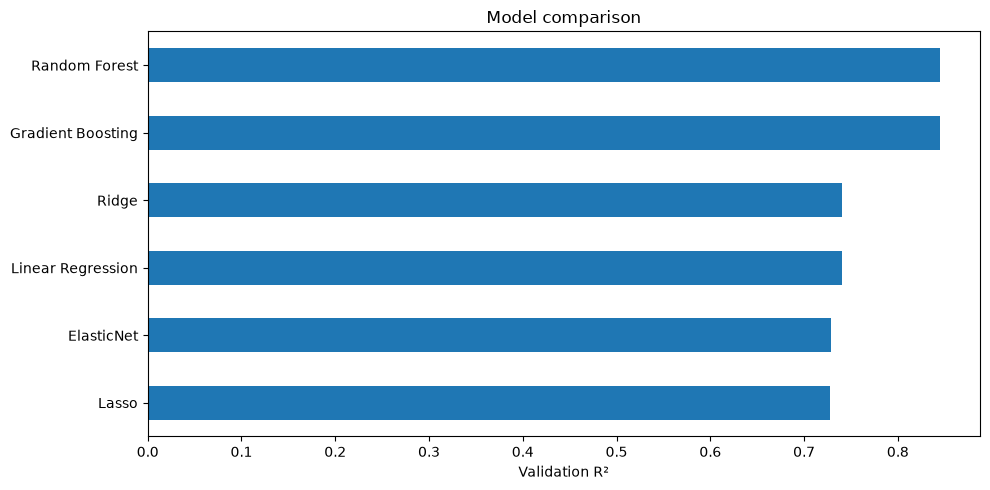

In [14]:
fig, ax = plt.subplots(figsize=(10, 5))
metrics_df['val_r2'].sort_values().plot(kind='barh', ax=ax)
ax.set_xlabel('Validation R²')
ax.set_title('Model comparison')
plt.tight_layout()
plt.show()

## 12. Tune the Best Model

Randomized search on the top model. This will take a minute or two.

In [15]:
param_grids = {
    'Random Forest': {
        'n_estimators': [100, 200, 300],
        'max_depth': [15, 20, 25, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
    },
    'Gradient Boosting': {
        'n_estimators': [100, 200],
        'learning_rate': [0.05, 0.1, 0.15],
        'max_depth': [3, 5, 7],
        'subsample': [0.8, 1.0],
    },
}

if best_model_name in param_grids:
    print(f"Tuning {best_model_name}...")
    search = RandomizedSearchCV(
        models[best_model_name],
        param_grids[best_model_name],
        n_iter=10,
        cv=3,
        scoring='r2',
        n_jobs=config.N_JOBS,
        random_state=config.RANDOM_STATE,
    )
    search.fit(X_train_processed, y_train)

    best_model = search.best_estimator_
    print(f"Best CV R²: {search.best_score_:.4f}")
    print(f"Best params: {search.best_params_}")

    y_val_pred = best_model.predict(X_val_processed)
    print(f"Tuned val R²: {r2_score(y_val, y_val_pred):.4f}")
else:
    print(f"{best_model_name} has no tuning grid. Using as-is.")

Tuning Random Forest...
Best CV R²: 0.8346
Best params: {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_depth': 25}
Tuned val R²: 0.8486


## 13. Test Set Evaluation

The test set has been held out since the split. This is the first and only time we look at it.

In [16]:
y_test_pred = best_model.predict(X_test_processed)

test_r2 = r2_score(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_mae = mean_absolute_error(y_test, y_test_pred)

print(f"Test R²:   {test_r2:.4f}")
print(f"Test RMSE: {test_rmse:.2f} min")
print(f"Test MAE:  {test_mae:.2f} min")
print(f"Avg trip:  {y_test.mean():.1f} min")
print(f"Relative error: {test_mae / y_test.mean() * 100:.1f}%")

Test R²:   0.8448
Test RMSE: 3.49 min
Test MAE:  2.22 min
Avg trip:  11.9 min
Relative error: 18.6%


## 14. Save the Model

`joblib.dump` writes the model and preprocessor to disk. Both are needed to serve predictions later.

In [17]:
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
output_dir = os.path.join(config.MODEL_DIR, timestamp)
os.makedirs(output_dir, exist_ok=True)

model_path = os.path.join(output_dir, 'model.pkl')
preprocessor_path = os.path.join(output_dir, 'preprocessor.pkl')

joblib.dump(best_model, model_path)
joblib.dump(preprocessor, preprocessor_path)

print(f"Saved to {output_dir}/")
print(f"  model.pkl")
print(f"  preprocessor.pkl")

Saved to models_nyc_taxi/20261004_214022/
  model.pkl
  preprocessor.pkl


## The Problem

You just trained 6 models and tuned the best one. Now close this notebook.

Reopen it tomorrow. What do you have?

- A folder with `model.pkl` and `preprocessor.pkl`. No metadata.
- No record of which model won, or why.
- No record of the hyperparameters.
- No record of the validation metrics.
- No record of the tuning search.
- No record of what data was used.

**You can't reproduce anything.** You can't compare this run to the next one. You can't tell which model in the folder is better. You can't trace the artifact back to the code that produced it.

That's the problem MLflow solves. Open `02-pipeline-tracked.ipynb`.